In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.colors as colors
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [2]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

In [3]:
t_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TREFHT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t_19['time'].values])
t_19 = t_19.assign_coords(time=shifted_time_19)
t_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TREFHT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t_19_c['time'].values])
t_19_c = t_19_c.assign_coords(time=shifted_time_19_c)
t_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TREFHT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t_22['time'].values])
t_22 = t_22.assign_coords(time=shifted_time_22)
t_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TREFHT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t_24['time'].values])
t_24 = t_24.assign_coords(time=shifted_time_24)
t_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t_1825_17tg['time'].values])
t_1825_17tg = t_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t_1825['time'].values])
t_1825 = t_1825.assign_coords(time=shifted_time_1825)
t_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TREFHT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t_1tg['time'].values])
t_1tg = t_1tg.assign_coords(time=shifted_time_1tg)
t_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TREFHT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t_1pr['time'].values])
t_1pr = t_1pr.assign_coords(time=shifted_time_1pr)
t_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TREFHT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t_60tg['time'].values])
t_60tg = t_60tg.assign_coords(time=shifted_time_60tg)

In [4]:
ocnmask_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/OCNFRAC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in ocnmask_19['time'].values])
ocnmask_19 = ocnmask_19.assign_coords(time=shifted_time_19)
ocnmask_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/OCNFRAC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in ocnmask_19_c['time'].values])
ocnmask_19_c = ocnmask_19_c.assign_coords(time=shifted_time_19_c)
ocnmask_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in ocnmask_22['time'].values])
ocnmask_22 = ocnmask_22.assign_coords(time=shifted_time_22)
ocnmask_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in ocnmask_24['time'].values])
ocnmask_24 = ocnmask_24.assign_coords(time=shifted_time_24)
ocnmask_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in ocnmask_1825_17tg['time'].values])
ocnmask_1825_17tg = ocnmask_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
ocnmask_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in ocnmask_1825['time'].values])
ocnmask_1825 = ocnmask_1825.assign_coords(time=shifted_time_1825)
ocnmask_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/OCNFRAC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in ocnmask_1tg['time'].values])
ocnmask_1tg = ocnmask_1tg.assign_coords(time=shifted_time_1tg)
ocnmask_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/OCNFRAC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in ocnmask_1pr['time'].values])
ocnmask_1pr = ocnmask_1pr.assign_coords(time=shifted_time_1pr)
ocnmask_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/OCNFRAC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in ocnmask_60tg['time'].values])
ocnmask_60tg = ocnmask_60tg.assign_coords(time=shifted_time_60tg)

In [5]:
landmask_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/LANDFRAC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in landmask_19['time'].values])
landmask_19 = landmask_19.assign_coords(time=shifted_time_19)
landmask_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/LANDFRAC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in landmask_19_c['time'].values])
landmask_19_c = landmask_19_c.assign_coords(time=shifted_time_19_c)
landmask_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in landmask_22['time'].values])
landmask_22 = landmask_22.assign_coords(time=shifted_time_22)
landmask_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in landmask_24['time'].values])
landmask_24 = landmask_24.assign_coords(time=shifted_time_24)
landmask_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in landmask_1825_17tg['time'].values])
landmask_1825_17tg = landmask_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
landmask_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in landmask_1825['time'].values])
landmask_1825 = landmask_1825.assign_coords(time=shifted_time_1825)
landmask_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/LANDFRAC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in landmask_1tg['time'].values])
landmask_1tg = landmask_1tg.assign_coords(time=shifted_time_1tg)
landmask_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/LANDFRAC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in landmask_1pr['time'].values])
landmask_1pr = landmask_1pr.assign_coords(time=shifted_time_1pr)
landmask_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/LANDFRAC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in landmask_60tg['time'].values])
landmask_60tg = landmask_60tg.assign_coords(time=shifted_time_60tg)

In [6]:
lat = t_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat))
lat = t_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = t_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = t_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = t_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = t_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = t_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = t_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = t_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [ ]:
exp_order = [
    "10Tg, 19km (all)",
    "10Tg, 19km",
    "10Tg, 22km",
    "17Tg, 24km",
    "10Tg, 18-25km",
    "17Tg, 18-25km",
    "10Tg, 19km (1% SO$_4$)",
    #"1Tg, 19km",
    #"60Tg, 19km"
]

colors = {
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    #"1Tg, 19km": "orange",
    #"60Tg, 19km": "cornflowerblue"
}

t2m_fields = {
    "10Tg, 19km (all)": t_19["TREFHT"],
    "10Tg, 19km": t_19_c["TREFHT"],
    "10Tg, 22km": t_22["TREFHT"],
    "17Tg, 24km": t_24["TREFHT"],
    "10Tg, 18-25km": t_1825["TREFHT"],
    "17Tg, 18-25km": t_1825_17tg["TREFHT"],
    "10Tg, 19km (1% SO$_4$)": t_1pr["TREFHT"],
    #"1Tg, 19km": t_1tg["TREFHT"],
    #"60Tg, 19km": t_60tg["TREFHT"]
}

landmask_fields = {
    "10Tg, 19km (all)": landmask_19["LANDFRAC"],
    "10Tg, 19km": landmask_19_c["LANDFRAC"],
    "10Tg, 22km": landmask_22["LANDFRAC"],
    "17Tg, 24km": landmask_24["LANDFRAC"],
    "10Tg, 18-25km": landmask_1825["LANDFRAC"],
    "17Tg, 18-25km": landmask_1825_17tg["LANDFRAC"],
    "10Tg, 19km (1% SO$_4$)": landmask_1pr["LANDFRAC"],
    #"1Tg, 19km": landmask_1tg["LANDFRAC"],
    #"60Tg, 19km": landmask_60tg["LANDFRAC"]
}

weights_dict = {
    "10Tg, 19km (all)": weighted_lat_19,
    "10Tg, 19km": weighted_lat_19_c,
    "10Tg, 22km": weighted_lat_22,
    "17Tg, 24km": weighted_lat_24,
    "10Tg, 18-25km": weighted_lat_1825,
    "17Tg, 18-25km": weighted_lat_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": weighted_lat_1pr,
    #"1Tg, 19km": weighted_lat_1tg,
    #"60Tg, 19km": weighted_lat_60tg
}

land_ts_dict = {}
ocean_ts_dict = {}

for name in exp_order:
    t2m = t2m_fields[name]
    landmask = landmask_fields[name]
    w = weights_dict[name]

    land_w = w * landmask
    ocean_w = w * (1 - landmask)

    land_ts_dict[name] = t2m.weighted(land_w).mean(dim=["lat", "lon"])
    ocean_ts_dict[name] = t2m.weighted(ocean_w).mean(dim=["lat", "lon"])

base_land = land_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))
base_ocean = ocean_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))

clim_land = base_land.groupby("time.month").mean("time")
clim_ocean = base_ocean.groupby("time.month").mean("time")

land_anom_dict = {}
ocean_anom_dict = {}

for name in exp_order:
    land_anom_dict[name] = land_ts_dict[name].groupby("time.month") - clim_land
    ocean_anom_dict[name] = ocean_ts_dict[name].groupby("time.month") - clim_ocean

<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_213566/1272368961.py:31: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


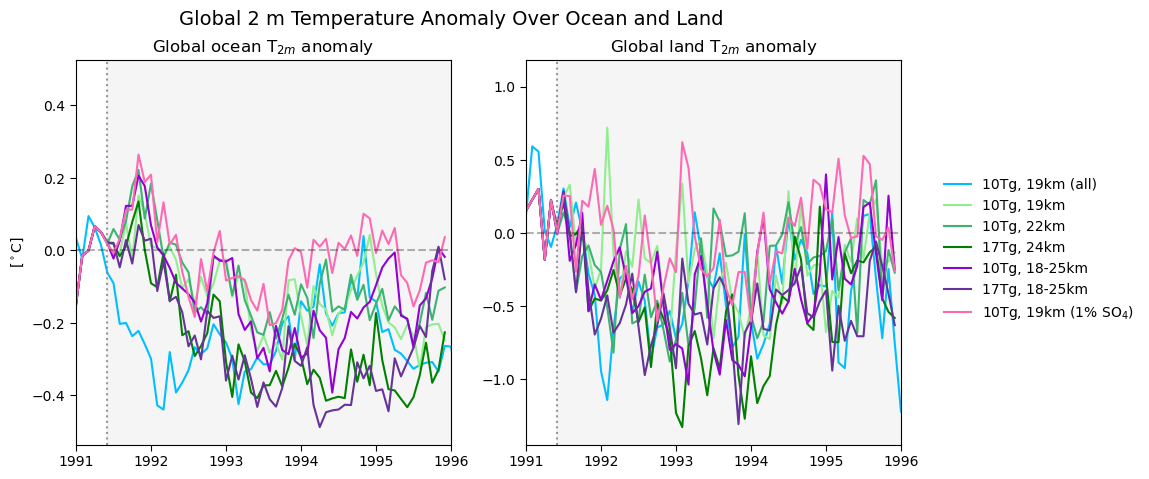

In [11]:
def to_float(x):
    if isinstance(x.time.values[0], np.datetime64):
        times = pd.DatetimeIndex(x.time.values)
        return [t.year + (t.month-1)/12 for t in times]
    else:
        return [t.year + (t.month-1)/12 for t in x.time.values]
    
    
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for name in exp_order:
    c = colors[name]

    ax[0].plot(to_float(ocean_anom_dict[name]), ocean_anom_dict[name], color=c, label=name)
    ax[1].plot(to_float(land_anom_dict[name]), land_anom_dict[name], color=c, label=name)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color="gray", alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global ocean T$_{2m}$ anomaly", fontsize=12)
ax[1].set_title("Global land T$_{2m}$ anomaly", fontsize=12)
ax[0].set_ylabel("[$^\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5), frameon=False)

fig.subplots_adjust(right=0.95)
fig.suptitle("Global 2 m Temperature Anomaly Over Ocean and Land", fontsize=14)

plt.show()

In [21]:
exp_order = [
    "10Tg, 19km (all)",
    "10Tg, 19km",
    "10Tg, 22km",
    "17Tg, 24km",
    "10Tg, 18-25km",
    "17Tg, 18-25km",
    "10Tg, 19km (1% SO$_4$)",
    "1Tg, 19km",
    "60Tg, 19km"
]

colors = {
    "10Tg, 19km (all)": "deepskyblue",
    "10Tg, 19km": "lightgreen",
    "10Tg, 22km": "mediumseagreen",
    "17Tg, 24km": "green",
    "10Tg, 18-25km": "darkviolet",
    "17Tg, 18-25km": "rebeccapurple",
    "10Tg, 19km (1% SO$_4$)": "hotpink",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

t2m_fields = {
    "10Tg, 19km (all)": t_19["TREFHT"],
    "10Tg, 19km": t_19_c["TREFHT"],
    "10Tg, 22km": t_22["TREFHT"],
    "17Tg, 24km": t_24["TREFHT"],
    "10Tg, 18-25km": t_1825["TREFHT"],
    "17Tg, 18-25km": t_1825_17tg["TREFHT"],
    "10Tg, 19km (1% SO$_4$)": t_1pr["TREFHT"],
    "1Tg, 19km": t_1tg["TREFHT"],
    "60Tg, 19km": t_60tg["TREFHT"]
}

landmask_fields = {
    "10Tg, 19km (all)": landmask_19["LANDFRAC"],
    "10Tg, 19km": landmask_19_c["LANDFRAC"],
    "10Tg, 22km": landmask_22["LANDFRAC"],
    "17Tg, 24km": landmask_24["LANDFRAC"],
    "10Tg, 18-25km": landmask_1825["LANDFRAC"],
    "17Tg, 18-25km": landmask_1825_17tg["LANDFRAC"],
    "10Tg, 19km (1% SO$_4$)": landmask_1pr["LANDFRAC"],
    "1Tg, 19km": landmask_1tg["LANDFRAC"],
    "60Tg, 19km": landmask_60tg["LANDFRAC"]
}

weights_dict = {
    "10Tg, 19km (all)": weighted_lat_19,
    "10Tg, 19km": weighted_lat_19_c,
    "10Tg, 22km": weighted_lat_22,
    "17Tg, 24km": weighted_lat_24,
    "10Tg, 18-25km": weighted_lat_1825,
    "17Tg, 18-25km": weighted_lat_1825_17tg,
    "10Tg, 19km (1% SO$_4$)": weighted_lat_1pr,
    "1Tg, 19km": weighted_lat_1tg,
    "60Tg, 19km": weighted_lat_60tg
}

land_ts_dict = {}
ocean_ts_dict = {}

for name in exp_order:
    t2m = t2m_fields[name]
    landmask = landmask_fields[name]
    w = weights_dict[name]

    land_w = w * landmask
    ocean_w = w * (1 - landmask)

    land_ts_dict[name] = t2m.weighted(land_w).mean(dim=["lat", "lon"])
    ocean_ts_dict[name] = t2m.weighted(ocean_w).mean(dim=["lat", "lon"])

base_land = land_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))
base_ocean = ocean_ts_dict["10Tg, 19km (all)"].sel(time=slice("1986-01", "1990-12"))

clim_land = base_land.groupby("time.month").mean("time")
clim_ocean = base_ocean.groupby("time.month").mean("time")

land_anom_dict = {}
ocean_anom_dict = {}

for name in exp_order:
    land_anom_dict[name] = land_ts_dict[name].groupby("time.month") - clim_land
    ocean_anom_dict[name] = ocean_ts_dict[name].groupby("time.month") - clim_ocean

for name in exp_order:
    land_anom_dict[name] = land_anom_dict[name].sel(time=slice(None, "1995-12"))
    ocean_anom_dict[name] = ocean_anom_dict[name].sel(time=slice(None, "1995-12"))

In [22]:
rows = []

for name in exp_order:
    ocean = ocean_anom_dict[name]
    land = land_anom_dict[name]

    i_ocn = ocean.argmin(dim="time")
    i_lnd = land.argmin(dim="time")

    t_ocn = ocean.time.isel(time=i_ocn).values.item()
    t_lnd = land.time.isel(time=i_lnd).values.item()

    v_ocn = float(ocean.isel(time=i_ocn).values)
    v_lnd = float(land.isel(time=i_lnd).values)

    lag_months = (t_ocn.year - t_lnd.year) * 12 + (t_ocn.month - t_lnd.month)

    rows.append({
        "Experiment": name,
        "Ocean min time": f"{t_ocn.year:04d}-{t_ocn.month:02d}",
        "Ocean min [°C]": round(v_ocn, 2),
        "Land min time": f"{t_lnd.year:04d}-{t_lnd.month:02d}",
        "Land min [°C]": round(v_lnd, 2),
        "Ocean minus land lag [months]": lag_months
    })

minima_df = pd.DataFrame(rows)
minima_df

,Experiment,Ocean min time,Ocean min [°C],Land min time,Land min [°C],Ocean minus land lag [months]
0,"10Tg, 19km (all)",1992-03,-0.44,1992-02,-1.14,1
1,"10Tg, 19km",1995-08,-0.33,1992-12,-0.73,32
2,"10Tg, 22km",1995-07,-0.26,1992-12,-0.88,31
3,"17Tg, 24km",1995-06,-0.43,1993-02,-1.33,28
4,"10Tg, 18-25km",1994-06,-0.39,1993-03,-1.04,15
5,"17Tg, 18-25km",1994-04,-0.49,1993-11,-1.31,5
6,"10Tg, 19km (1% SO$_4$)",1993-08,-0.21,1994-01,-0.61,-5
7,"1Tg, 19km",1991-01,-0.15,1994-12,-0.26,-47
8,"60Tg, 19km",1993-11,-1.53,1993-11,-3.13,0


In [23]:
rows = []

for name in exp_order:
    ocean = ocean_anom_dict[name].sel(time=slice("1991-06", "1993-12"))
    land = land_anom_dict[name].sel(time=slice("1991-06", "1993-12"))

    i_ocn = ocean.argmin(dim="time")
    i_lnd = land.argmin(dim="time")

    t_ocn = ocean.time.isel(time=i_ocn).values.item()
    t_lnd = land.time.isel(time=i_lnd).values.item()

    v_ocn = float(ocean.isel(time=i_ocn).values)
    v_lnd = float(land.isel(time=i_lnd).values)

    lag_months = (t_ocn.year - t_lnd.year) * 12 + (t_ocn.month - t_lnd.month)

    rows.append({
        "Experiment": name,
        "Ocean min time": f"{t_ocn.year:04d}-{t_ocn.month:02d}",
        "Ocean min [°C]": round(v_ocn, 2),
        "Land min time": f"{t_lnd.year:04d}-{t_lnd.month:02d}",
        "Land min [°C]": round(v_lnd, 2),
        "Ocean minus land lag [months]": lag_months
    })

minima_df_window = pd.DataFrame(rows)
minima_df_window

,Experiment,Ocean min time,Ocean min [°C],Land min time,Land min [°C],Ocean minus land lag [months]
0,"10Tg, 19km (all)",1992-03,-0.44,1992-02,-1.14,1
1,"10Tg, 19km",1993-10,-0.30,1992-12,-0.73,10
2,"10Tg, 22km",1993-09,-0.24,1992-12,-0.88,9
3,"17Tg, 24km",1993-06,-0.41,1993-02,-1.33,4
4,"10Tg, 18-25km",1993-08,-0.33,1993-03,-1.04,5
5,"17Tg, 18-25km",1993-06,-0.43,1993-11,-1.31,-5
6,"10Tg, 19km (1% SO$_4$)",1993-08,-0.21,1992-10,-0.60,10
7,"1Tg, 19km",1991-08,-0.02,1992-11,-0.22,-15
8,"60Tg, 19km",1993-11,-1.53,1993-11,-3.13,0


In [13]:
exp_order = [
    "10Tg, 19km",
    "1Tg, 19km",
    "60Tg, 19km"
]

colors = {
    "10Tg, 19km": "lightgreen",
    "1Tg, 19km": "orange",
    "60Tg, 19km": "cornflowerblue"
}

t2m_fields = {
    "10Tg, 19km": t_19_c["TREFHT"],
    "1Tg, 19km": t_1tg["TREFHT"],
    "60Tg, 19km": t_60tg["TREFHT"]
}

landmask_fields = {
    "10Tg, 19km": landmask_19_c["LANDFRAC"],
    "1Tg, 19km": landmask_1tg["LANDFRAC"],
    "60Tg, 19km": landmask_60tg["LANDFRAC"]
}

weights_dict = {
    "10Tg, 19km": weighted_lat_19_c,
    "1Tg, 19km": weighted_lat_1tg,
    "60Tg, 19km": weighted_lat_60tg
}

land_ts_dict = {}
ocean_ts_dict = {}

for name in exp_order:
    t2m = t2m_fields[name]
    landmask = landmask_fields[name]
    w = weights_dict[name]

    land_w = w * landmask
    ocean_w = w * (1 - landmask)

    land_ts_dict[name] = t2m.weighted(land_w).mean(dim=["lat", "lon"])
    ocean_ts_dict[name] = t2m.weighted(ocean_w).mean(dim=["lat", "lon"])

clim_land = base_land.groupby("time.month").mean("time")
clim_ocean = base_ocean.groupby("time.month").mean("time")

land_anom_dict = {}
ocean_anom_dict = {}

for name in exp_order:
    land_anom_dict[name] = land_ts_dict[name].groupby("time.month") - clim_land
    ocean_anom_dict[name] = ocean_ts_dict[name].groupby("time.month") - clim_ocean

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_213566/710154999.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


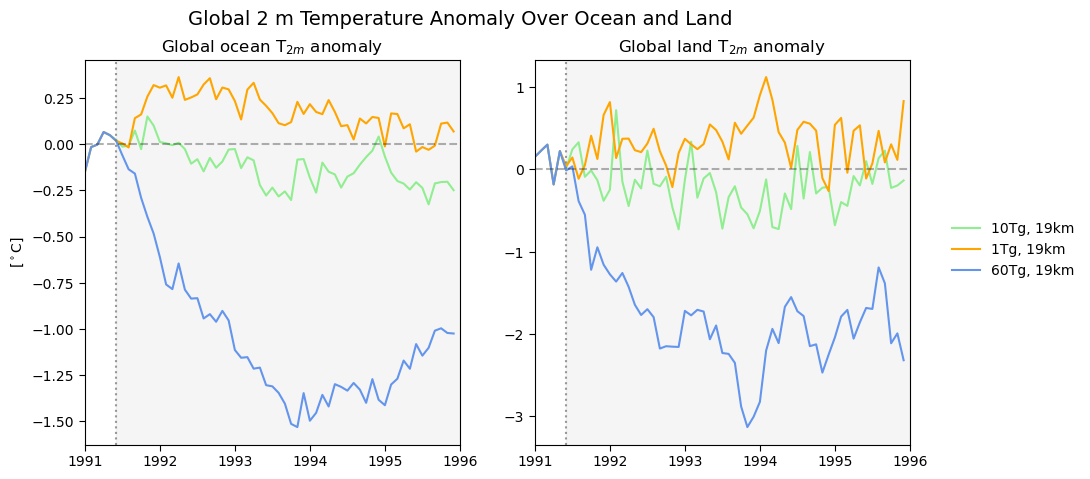

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for name in exp_order:
    c = colors[name]

    ax[0].plot(to_float(ocean_anom_dict[name]), ocean_anom_dict[name], color=c, label=name)
    ax[1].plot(to_float(land_anom_dict[name]), land_anom_dict[name], color=c, label=name)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color="gray", alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global ocean T$_{2m}$ anomaly", fontsize=12)
ax[1].set_title("Global land T$_{2m}$ anomaly", fontsize=12)
ax[0].set_ylabel("[$^\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5), frameon=False)

fig.subplots_adjust(right=0.95)
fig.suptitle("Global 2 m Temperature Anomaly Over Ocean and Land", fontsize=14)

plt.show()

TypeError: Cannot convert input [1995-08-01 00:00:00] of type <class 'numpy.ndarray'> to Timestamp

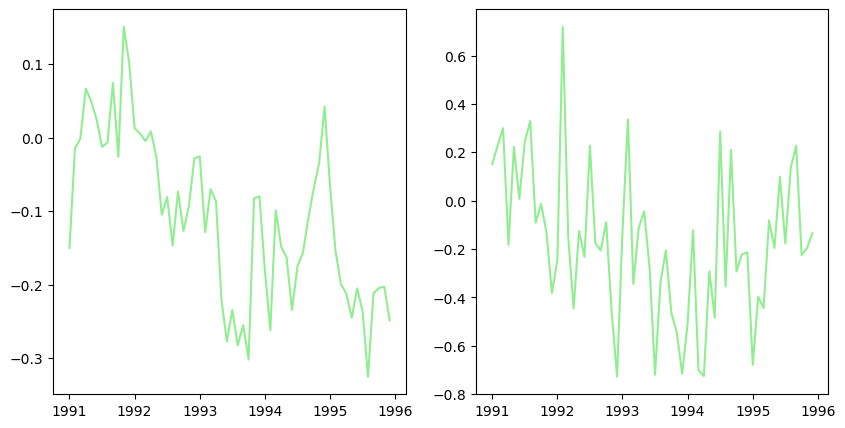

In [16]:
key_cases = ["10Tg, 19km", "1Tg, 19km", "60Tg, 19km"]
def time_to_float(t):
    t = pd.Timestamp(t.values)
    return t.year + (t.month - 1) / 12


fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for name in key_cases:
    c = colors[name]

    ocean = ocean_anom_dict[name]
    land = land_anom_dict[name]

    ax[0].plot(to_float(ocean), ocean, color=c, label=name)
    ax[1].plot(to_float(land), land, color=c, label=name)

    i_ocn = ocean.argmin(dim="time")
    i_lnd = land.argmin(dim="time")

    t_ocn = ocean.time.isel(time=i_ocn)
    t_lnd = land.time.isel(time=i_lnd)

    v_ocn = ocean.isel(time=i_ocn)
    v_lnd = land.isel(time=i_lnd)

    ax[0].scatter(time_to_float(t_ocn), float(v_ocn.values), color=c, s=45, zorder=6)
    ax[1].scatter(time_to_float(t_lnd), float(v_lnd.values), color=c, s=45, zorder=6)

    ax[0].text(time_to_float(t_ocn) + 0.03, float(v_ocn.values), str(t_ocn.values)[:7], color=c, fontsize=9)
    ax[1].text(time_to_float(t_lnd) + 0.03, float(v_lnd.values), str(t_lnd.values)[:7], color=c, fontsize=9)

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996 + (1 - 1) / 12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color="gray", alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.3)
    a.set_xlim(1991, 1996)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.tick_params(direction="out", length=4)

ax[0].set_title("Global ocean $T_{2m}$ anomaly", fontsize=12)
ax[1].set_title("Global land $T_{2m}$ anomaly", fontsize=12)
ax[0].set_ylabel("[$^\\circ$C]")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.98, 0.5), frameon=False)

fig.subplots_adjust(right=0.85)
fig.suptitle("Timing of minimum $T_{2m}$ anomaly over ocean and land", fontsize=14)

plt.show()